# *01 - Data Understanding & Exploratory Data Analysis (EDA)*
Objective:
- Understand data structure and feature types
- Examine class imbalance in Diabetes_012
- Support the decision of binary vs multi-class classification


## 1.1 load library & dataset

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# display setting
pd.set_option('display.max_columns', 50)
sns.set(style="whitegrid")

df = pd.read_csv("../data/CDC Diabetes Dataset.csv")

df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [4]:
df.describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
1%,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,1.000000
5%,0.000000,0.000000,0.000000,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,2.000000
95%,2.000000,1.000000,1.000000,1.000000,40.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,26.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000
99%,2.000000,1.000000,1.000000,1.000000,50.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


low-variance features may be removed prior to clustering
-- CholCheck, Stroke

In [5]:
df.shape

(253680, 22)

## 1.2 raw data check and visualization

check target feature:

In [6]:
target_counts = df["Diabetes_012"].value_counts().sort_index()
target_counts


Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

In [7]:
target_ratio = df["Diabetes_012"].value_counts(normalize=True).sort_index()
target_ratio


Diabetes_012
0.0    0.842412
1.0    0.018255
2.0    0.139333
Name: proportion, dtype: float64

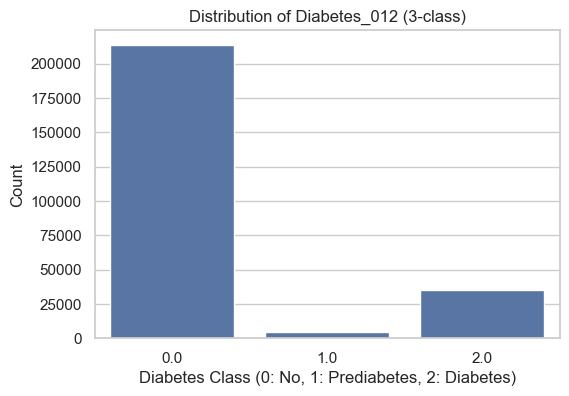

In [26]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)
plt.title("Distribution of Diabetes_012 (3-class)")
plt.xlabel("Diabetes Class (0: No, 1: Prediabetes, 2: Diabetes)")
plt.ylabel("Count")
plt.show()


In [8]:
df["target"] = df["Diabetes_012"].apply(lambda x: 0 if x == 0 else 1).astype(int)


binary_counts = df["target"].value_counts()
binary_ratio = df["target"].value_counts(normalize=True)

binary_counts, binary_ratio


(target
 0    213703
 1     39977
 Name: count, dtype: int64,
 target
 0    0.842412
 1    0.157588
 Name: proportion, dtype: float64)

Due to the severe imbalance of the prediabetes class in the original three-class formulation, the problem was reformulated as a binary classification task to improve model stability and practical relevance for public health screening.

check numeric features:

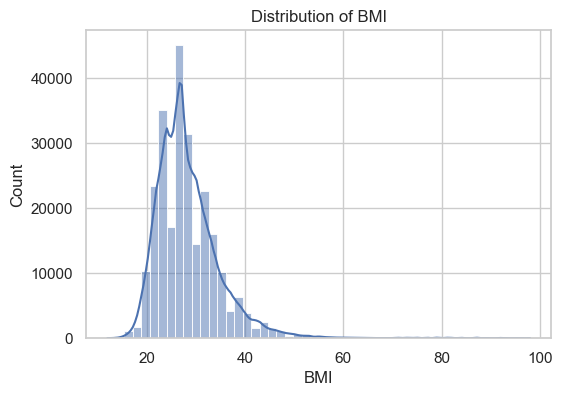

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df["BMI"], bins=50, kde=True)
plt.title("Distribution of BMI")
plt.show()


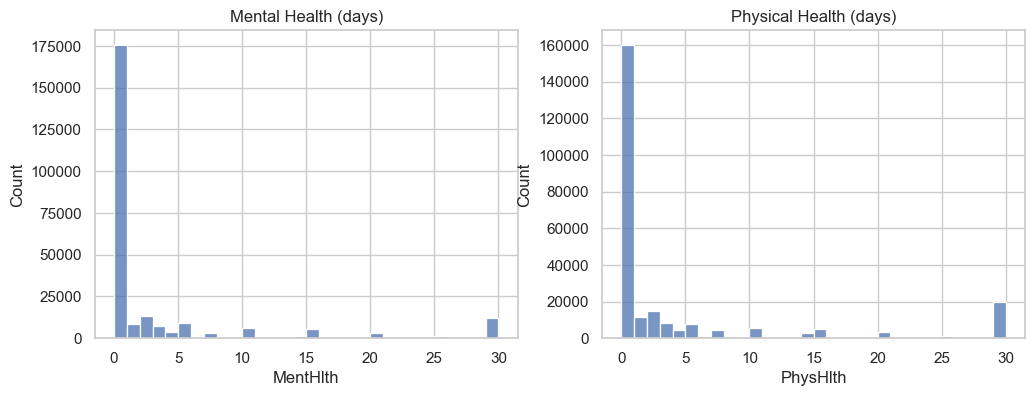

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df["MentHlth"], bins=30, ax=axes[0])
axes[0].set_title("Mental Health (days)")

sns.histplot(df["PhysHlth"], bins=30, ax=axes[1])
axes[1].set_title("Physical Health (days)")

plt.show()


skeness, long tail, lots of zero, right skewed

check binary features:

In [11]:
binary_features = [
    "HighBP", "HighChol", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity",
    "Fruits", "Veggies", "HvyAlcoholConsump",
    "DiffWalk"
]

binary_summary = df[binary_features].mean().sort_values(ascending=False)
binary_summary


Veggies                 0.811420
PhysActivity            0.756544
Fruits                  0.634256
Smoker                  0.443169
HighBP                  0.429001
HighChol                0.424121
DiffWalk                0.168224
HeartDiseaseorAttack    0.094186
HvyAlcoholConsump       0.056197
Stroke                  0.040571
dtype: float64

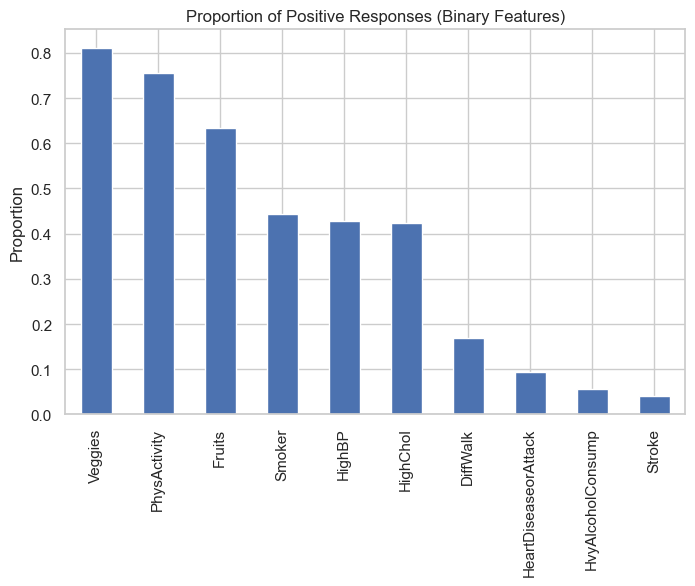

In [12]:
plt.figure(figsize=(8,5))
binary_summary.plot(kind="bar")
plt.title("Proportion of Positive Responses (Binary Features)")
plt.ylabel("Proportion")
plt.show()

Binary features with proportions close to 0.5 were preferred for clustering, as they provide higher variance and therefore stronger discriminative power.

Features with extremely imbalanced distributions (e.g., near-constant 0 or 1) were excluded, as they contribute little to distance-based clustering algorithms.

we could find that ['PhysActivity', 'Fruits', 'Smoker', 'HighBP', 'HighChol'] are aroud 0.5 (0.2< p <0.8)

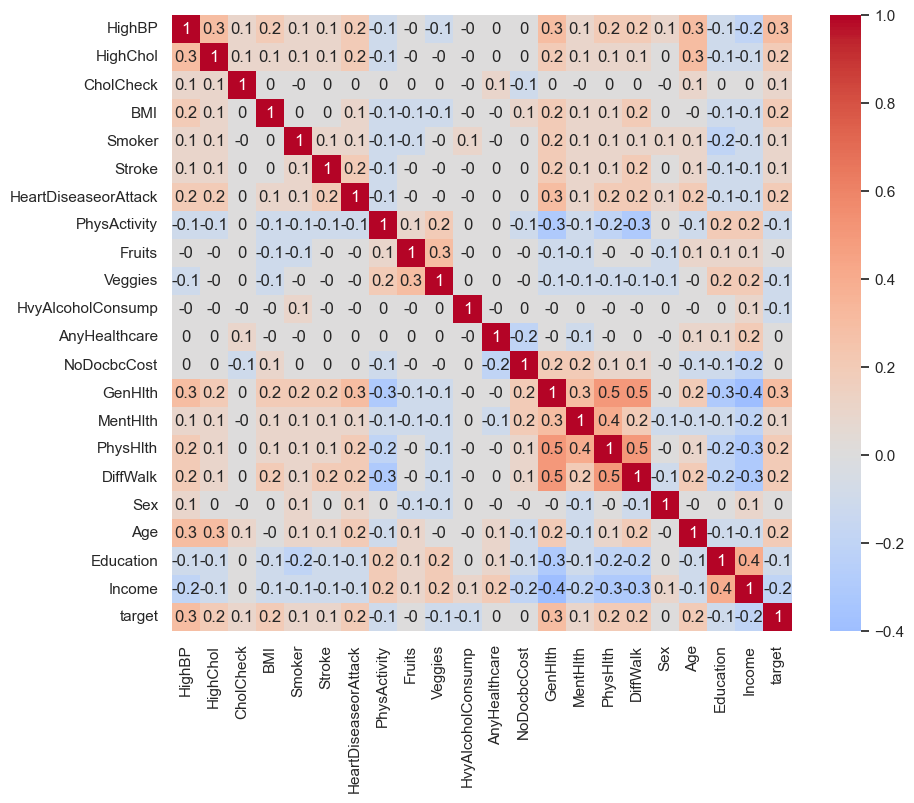

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr().round(1), cmap='coolwarm', center=0, annot=True)
plt.show()


Highly correlated features may introduce redundancy and distort distance-based clustering results.

In [15]:
X = df.drop(columns=['Diabetes_012', 'target'])
y = df['target']

df.drop(columns=['Diabetes_012'], inplace=True)
processed_path = "../data/diabetes_processed.csv"
df.to_csv(processed_path, index=False)

In [17]:
binary_cols = [c for c in X.columns if df[c].dropna().isin([0,1]).all()]
continuous_cols = [c for c in X.columns if c not in binary_cols]


BMI: p-value = 0.0000
GenHlth: p-value = 0.0000
MentHlth: p-value = 0.0000
PhysHlth: p-value = 0.0000
Age: p-value = 0.0000
Education: p-value = 0.0000
Income: p-value = 0.0000


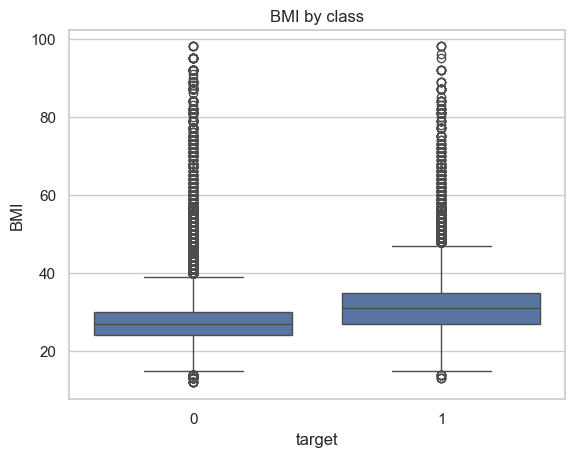

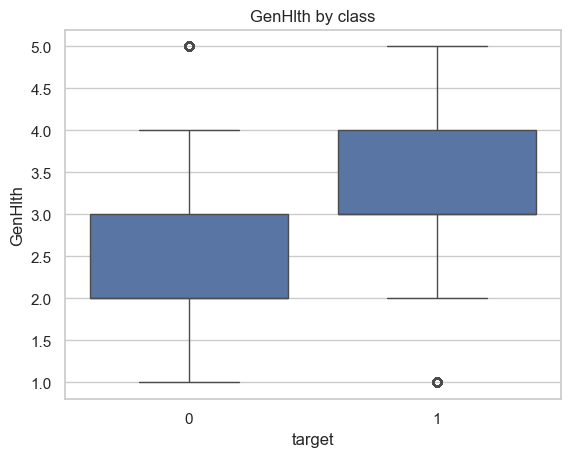

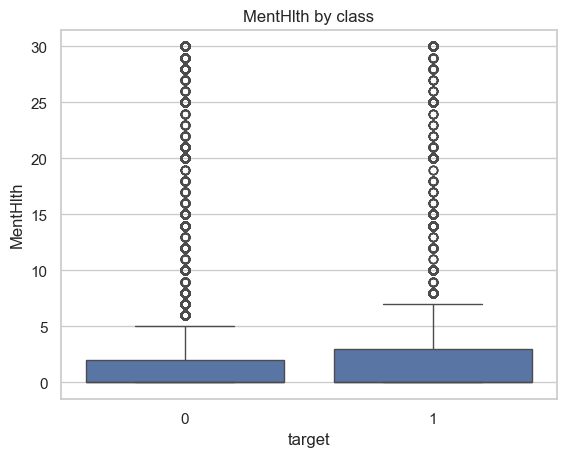

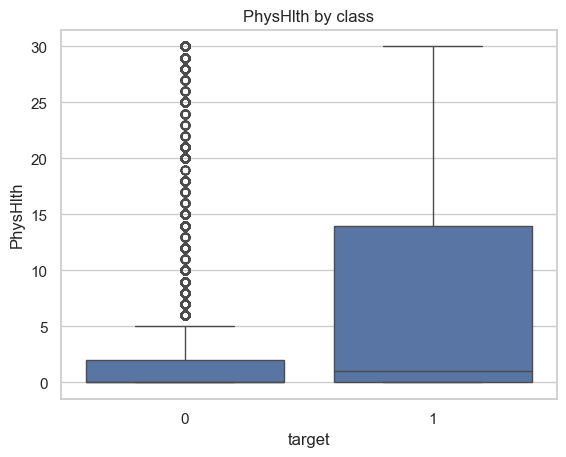

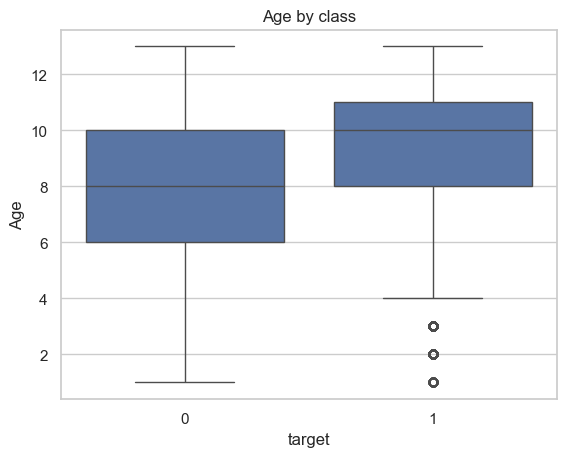

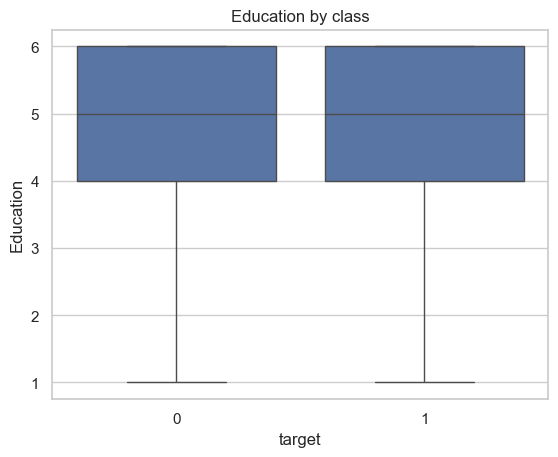

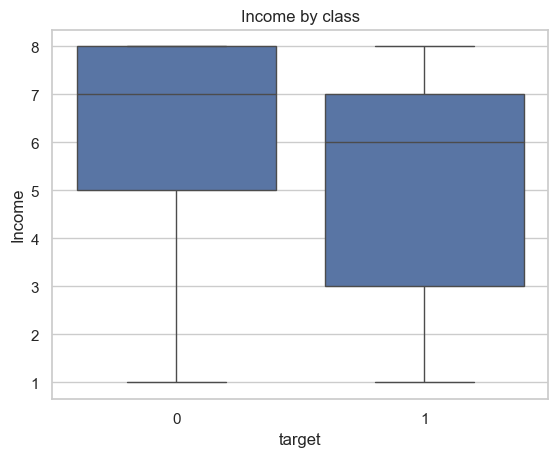

In [19]:
from scipy.stats import mannwhitneyu

for col in continuous_cols:
    group0 = df[df['target']==0][col]
    group1 = df[df['target']==1][col]
    stat, p = mannwhitneyu(group0, group1)
    print(f"{col}: p-value = {p:.4f}")

for col in continuous_cols:
    sns.boxplot(x=y, y=X[col])
    plt.title(f"{col} by class")
    plt.show()


Boxplots were used to examine distributional differences of continuous features across classes.
Boxplot analysis reveals that BMI, general health, and age class show clear distributional shifts across diabetes categories. 

HighBP: p-value = 0.0000
HighChol: p-value = 0.0000
Smoker: p-value = 0.0000
Stroke: p-value = 0.0000
HeartDiseaseorAttack: p-value = 0.0000
PhysActivity: p-value = 0.0000
Fruits: p-value = 0.0000
Veggies: p-value = 0.0000
HvyAlcoholConsump: p-value = 0.0000
DiffWalk: p-value = 0.0000


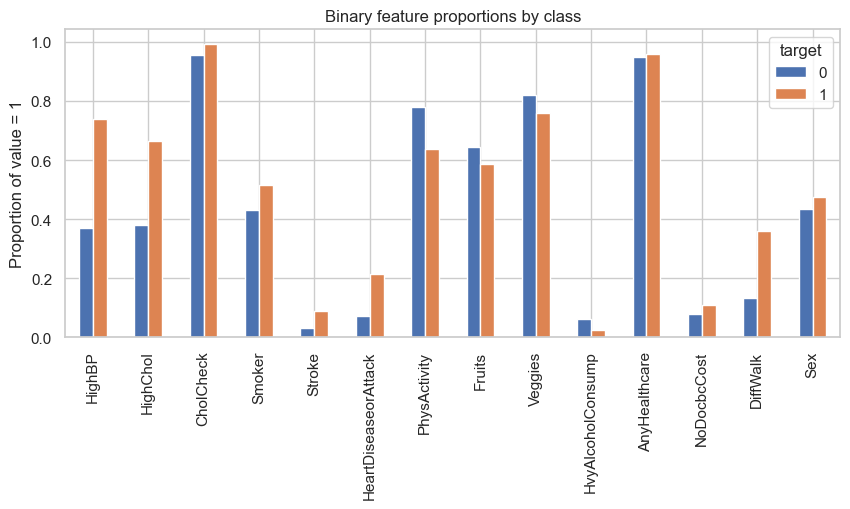

In [20]:
binary_summary = (
    X[binary_cols]
    .groupby(y)
    .mean()
    .T
)
from scipy.stats import chi2_contingency

for col in binary_features:
    table = pd.crosstab(df[col], df['target'])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"{col}: p-value = {p:.4f}")
    
binary_summary.plot(kind='bar', figsize=(10,4))
plt.ylabel("Proportion of value = 1")
plt.title("Binary feature proportions by class")
plt.show()

Binary health indicators such as high blood pressure and heart disease demonstrate increasing prevalence in diabetic groups. However, some lifestyle indicators (e.g., physactivity, fruit and vegetable consumption) show weaker differentiation, suggesting limited discriminative power when used in isolation.